# HPC Parcial 1 — Desarrollo y Experimentación

Este notebook documenta el desarrollo del programa (función de prueba y versiones secuencial/paralela) y la experimentación (medición de tiempos, speedup y eficiencia). El análisis completo de los resultados está en `README.md`.

## 1. Desarrollo del programa

Se implementó la función de prueba:

$$f(x) = \sqrt{x} + x^2 + \sin(x) + \cos(x) + \log(x)$$

en `src/compute.py`, junto con una versión **secuencial** (procesa todo el arreglo en un solo proceso) y la lógica de división en chunks para la versión **paralela** (implementada con `ProcessPoolExecutor` en `src/benchmark.py`).

In [1]:
import sys
sys.path.insert(0, 'src')
from compute import run_sequential
import numpy as np

# Demostracion rapida con un arreglo pequeno
sample = np.linspace(1.0, 10.0, 5)
print('Entrada:', sample)
print('f(x):   ', run_sequential(sample))

Entrada: [ 1.    3.25  5.5   7.75 10.  ]
f(x):    [  3.38177329  12.44160582  34.30308542  65.99246816 104.08177011]


## 2. Experimentación

El benchmark real (multiprocessing con 1, 2 y 4 workers, 3 repeticiones cada uno) se corre como script independiente (`src/benchmark.py`), no dentro de este notebook — `ProcessPoolExecutor` no serializa de forma confiable funciones definidas en el kernel de Jupyter. El resultado se guarda en `results/results.csv` y se carga aquí para mostrarlo.

In [2]:
!python src/benchmark.py --size 20000000 --workers 1 2 4 --repeats 3

workers=1 prueba=1 tiempo=1.2556s


workers=1 prueba=2 tiempo=1.2214s


workers=1 prueba=3 tiempo=1.1929s
-> workers=1 promedio=1.2233s



workers=2 prueba=1 tiempo=1.8467s


workers=2 prueba=2 tiempo=1.8301s


workers=2 prueba=3 tiempo=1.8462s
-> workers=2 promedio=1.8410s



workers=4 prueba=1 tiempo=1.4040s


workers=4 prueba=2 tiempo=1.3714s


workers=4 prueba=3 tiempo=1.4044s
-> workers=4 promedio=1.3933s

Resultados guardados en results/results.csv


### Resultados

In [3]:
import csv

with open('results/results.csv', newline='') as f_in:
    reader = csv.DictReader(f_in)
    rows = list(reader)

header = list(rows[0].keys())
print(' | '.join(f'{h:>12}' for h in header))
for row in rows:
    vals = [row['workers']] + [f'{float(row[h]):.4f}' for h in header[1:]]
    print(' | '.join(f'{v:>12}' for v in vals))

     workers |     prueba_1 |     prueba_2 |     prueba_3 |     promedio |      speedup |   eficiencia
           1 |       1.2005 |       1.1866 |       1.1992 |       1.1955 |       1.0000 |       1.0000
           2 |       1.7956 |       1.7744 |       1.7830 |       1.7843 |       0.6700 |       0.3350
           4 |       1.3038 |       1.3385 |       1.3734 |       1.3386 |       0.8931 |       0.2233


## 3. Gráfica de rendimiento

En esta sección se generan las gráficas de rendimiento directamente en el notebook, a partir de `results/results.csv` y `results/results_heavy.csv`. Para cada conjunto de datos se producen tres gráficas: workers vs. tiempo promedio, workers vs. speedup (comparado con el ideal), y workers vs. eficiencia (comparada con el ideal de 1.0). Las imágenes se guardan en `results/performance_plot.png` y `results/performance_plot_heavy.png`.

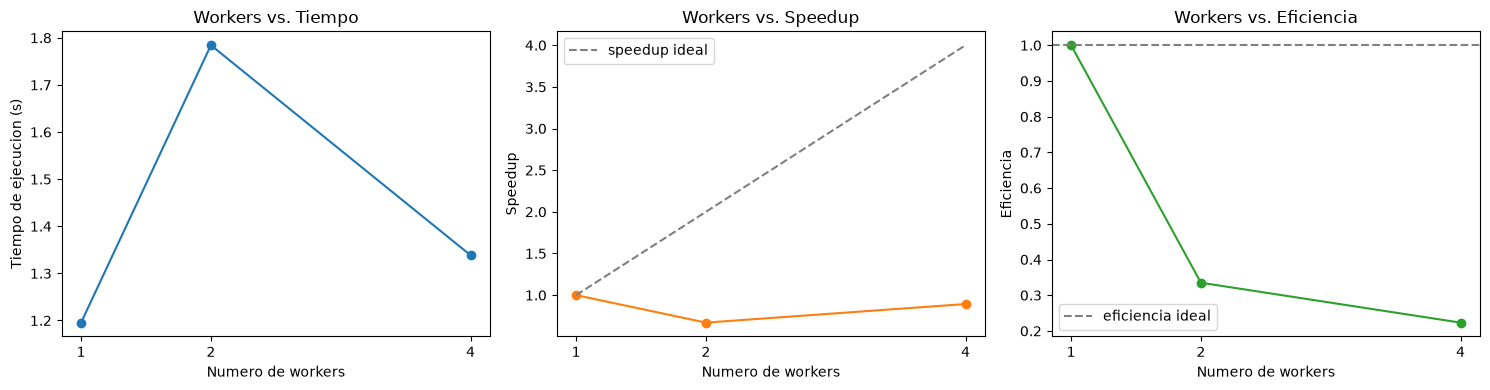

Grafica guardada en results/performance_plot.png


In [4]:
import csv
import matplotlib.pyplot as plt


def load_results(path):
    with open(path, newline='') as f:
        reader = csv.DictReader(f)
        rows = [
            {
                "workers": int(r["workers"]),
                "promedio": float(r["promedio"]),
                "speedup": float(r["speedup"]),
                "eficiencia": float(r["eficiencia"]),
            }
            for r in reader
        ]
    return sorted(rows, key=lambda r: r["workers"])


def plot_performance(path_csv, path_png, title_suffix=""):
    rows = load_results(path_csv)
    workers = [r["workers"] for r in rows]
    tiempos = [r["promedio"] for r in rows]
    speedups = [r["speedup"] for r in rows]
    eficiencias = [r["eficiencia"] for r in rows]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(workers, tiempos, marker="o")
    axes[0].set_xlabel("Numero de workers")
    axes[0].set_ylabel("Tiempo de ejecucion (s)")
    axes[0].set_title(f"Workers vs. Tiempo{title_suffix}")
    axes[0].set_xticks(workers)

    axes[1].plot(workers, speedups, marker="o", color="tab:orange")
    axes[1].plot(workers, workers, linestyle="--", color="gray", label="speedup ideal")
    axes[1].set_xlabel("Numero de workers")
    axes[1].set_ylabel("Speedup")
    axes[1].set_title(f"Workers vs. Speedup{title_suffix}")
    axes[1].set_xticks(workers)
    axes[1].legend()

    axes[2].plot(workers, eficiencias, marker="o", color="tab:green")
    axes[2].axhline(1.0, linestyle="--", color="gray", label="eficiencia ideal")
    axes[2].set_xlabel("Numero de workers")
    axes[2].set_ylabel("Eficiencia")
    axes[2].set_title(f"Workers vs. Eficiencia{title_suffix}")
    axes[2].set_xticks(workers)
    axes[2].legend()

    fig.tight_layout()
    fig.savefig(path_png, dpi=150)
    plt.show()
    print(f"Grafica guardada en {path_png}")


plot_performance("results/results.csv", "results/performance_plot.png")

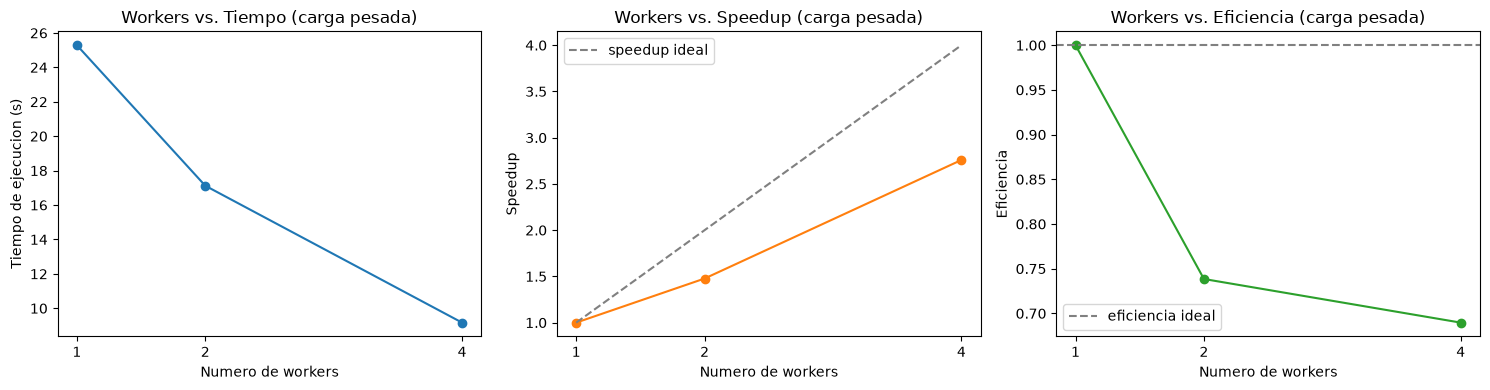

Grafica guardada en results/performance_plot_heavy.png


In [5]:
plot_performance("results/results_heavy.csv", "results/performance_plot_heavy.png", title_suffix=" (carga pesada)")

## 4. Experimento adicional: carga computacional mayor

En el experimento anterior, `f(x)` es barata (NumPy la calcula sobre 20M elementos en ~1.2 s), por lo que el costo de copiar el arreglo a cada proceso y traer los resultados de vuelta domina sobre el ahorro de paralelizar — por eso el speedup fue menor a 1. Para ilustrar el caso opuesto (cómputo dominante), se repite el experimento con `f_heavy`, que hace mucho más trabajo por elemento.

In [6]:
!python src/benchmark.py --heavy --size 2000000 --workers 1 2 4 --repeats 3

workers=1 prueba=1 tiempo=25.4239s


workers=1 prueba=2 tiempo=25.6829s


workers=1 prueba=3 tiempo=25.6557s
-> workers=1 promedio=25.5875s



workers=2 prueba=1 tiempo=17.5366s


workers=2 prueba=2 tiempo=17.3807s


workers=2 prueba=3 tiempo=17.6292s
-> workers=2 promedio=17.5155s



workers=4 prueba=1 tiempo=9.7018s


workers=4 prueba=2 tiempo=9.6139s


workers=4 prueba=3 tiempo=9.6334s
-> workers=4 promedio=9.6497s

Resultados guardados en results/results_heavy.csv


### Resultados (carga pesada)

In [7]:
import csv

with open('results/results_heavy.csv', newline='') as f_in:
    reader = csv.DictReader(f_in)
    rows = list(reader)

header = list(rows[0].keys())
print(' | '.join(f'{h:>12}' for h in header))
for row in rows:
    vals = [row['workers']] + [f'{float(row[h]):.4f}' for h in header[1:]]
    print(' | '.join(f'{v:>12}' for v in vals))

     workers |     prueba_1 |     prueba_2 |     prueba_3 |     promedio |      speedup |   eficiencia
           1 |      25.2975 |      25.2357 |      25.3283 |      25.2872 |       1.0000 |       1.0000
           2 |      17.1378 |      17.1711 |      17.0548 |      17.1213 |       1.4769 |       0.7385
           4 |       9.1960 |       9.1794 |       9.1235 |       9.1663 |       2.7587 |       0.6897
